# JPMC Take Home Project

**Name:** Shivani Madan

**Email ID:** shivanimadan1099@gmail.com

---

<a id='part1'></a>
# 1. Classification Problem

<a id='data-understanding'></a>
## 1.1 Data Understanding

### 1.1.1 Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve,accuracy_score, f1_score,auc


from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBClassifier

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
with open('census-bureau.columns', 'r') as f:
    column_names = [line.strip() for line in f.readlines()]

In [4]:
print(column_names)

['age', 'class of worker', 'detailed industry recode', 'detailed occupation recode', 'education', 'wage per hour', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'capital gains', 'capital losses', 'dividends from stocks', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'weight', 'migration code-change in msa', 'migration code-change in reg', 'migration code-move within reg', 'live in this house 1 year ago', 'migration prev res in sunbelt', 'num persons worked for employer', 'family members under 18', 'country of birth father', 'country of birth mother', 'country of birth self', 'citizenship', 'own business or self employed', "fill inc questionnaire for veteran's admin", 'veterans benefits', 'weeks worked 

In [5]:
df = pd.read_csv('census-bureau.data', names=column_names, skipinitialspace=True)

In [6]:
print(f"Dataset Shape: {df.shape}")
print(f"Number of features: {len(column_names) - 2}")  # This is to exclude the weight and target

Dataset Shape: (199523, 42)
Number of features: 40


In [7]:
df.head(5)

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


In [8]:
df.tail(5)

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
199518,87,Not in universe,0,0,7th and 8th grade,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,...,Canada,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
199519,65,Self-employed-incorporated,37,2,11th grade,0,Not in universe,Married-civilian spouse present,Business and repair services,Executive admin and managerial,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
199520,47,Not in universe,0,0,Some college but no degree,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,...,Poland,Poland,Germany,Foreign born- U S citizen by naturalization,0,Not in universe,2,52,95,- 50000.
199521,16,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
199522,32,Private,42,30,High school graduate,0,Not in universe,Never married,Medical except hospital,Other service,...,?,?,?,Foreign born- Not a citizen of U S,0,Not in universe,2,52,94,- 50000.


**Note:** The dataset contains '?' entries which represents missing values and will be handled later during preprocessing.

<a id='eda'></a>
## 1.2 Exploratory Data Analysis (EDA)

<a id='stats'></a>
### 1.2.1 Statistical Summary

Basic Statistical Understanding

In [9]:
print("\n Dataset Information:")
print(df.info())


 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199523 entries, 0 to 199522
Data columns (total 42 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   age                                         199523 non-null  int64  
 1   class of worker                             199523 non-null  object 
 2   detailed industry recode                    199523 non-null  int64  
 3   detailed occupation recode                  199523 non-null  int64  
 4   education                                   199523 non-null  object 
 5   wage per hour                               199523 non-null  int64  
 6   enroll in edu inst last wk                  199523 non-null  object 
 7   marital stat                                199523 non-null  object 
 8   major industry code                         199523 non-null  object 
 9   major occupation code                       199

In [10]:
# Checking each columns unique values
for col in df.columns:
    unique_count = df[col].nunique()
    if unique_count < 50: 
        print(f"\n{col} ({unique_count} unique):")
        print(df[col].value_counts())



class of worker (9 unique):
class of worker
Not in universe                   100245
Private                            72028
Self-employed-not incorporated      8445
Local government                    7784
State government                    4227
Self-employed-incorporated          3265
Federal government                  2925
Never worked                         439
Without pay                          165
Name: count, dtype: int64

detailed occupation recode (47 unique):
detailed occupation recode
0     100684
2       8756
26      7887
19      5413
29      5105
36      4145
34      4025
10      3683
16      3445
23      3392
12      3340
33      3325
3       3195
35      3168
38      3003
31      2699
32      2398
37      2234
8       2151
42      1918
30      1897
24      1847
17      1771
28      1661
41      1592
44      1592
43      1382
4       1364
13      1271
18      1083
39      1017
14       932
5        855
15       815
27       780
25       767
9        738
7        73

In [11]:
def classify_cardinality(unique_count):
    if unique_count == 1:
        return 'Constant'
    elif unique_count == 2:
        return 'Binary'
    elif unique_count <= 10:
        return 'Low'
    elif unique_count <= 50:
        return 'Medium'
    else:
        return 'High'

cardinality_dict = {
    'Constant': [],
    'Binary': [],
    'Low': [],
    'Medium': [],
    'High': []
}

for col in df.columns:
    unique = df[col].nunique()
    cardinality = classify_cardinality(unique)
    cardinality_dict[cardinality].append(f"{col} ({unique})")

print("CARDINALITY ANALYSIS")

for cardinality_type, columns in cardinality_dict.items():
    if columns:
        print(f"\n{cardinality_type.upper()} CARDINALITY ({len(columns)} columns):")
        print("-" * 100)
        for col_info in columns:
            print(f"  • {col_info}")


CARDINALITY ANALYSIS

BINARY CARDINALITY (3 columns):
----------------------------------------------------------------------------------------------------
  • sex (2)
  • year (2)
  • label (2)

LOW CARDINALITY (22 columns):
----------------------------------------------------------------------------------------------------
  • class of worker (9)
  • enroll in edu inst last wk (3)
  • marital stat (7)
  • race (5)
  • hispanic origin (9)
  • member of a labor union (3)
  • reason for unemployment (6)
  • full or part time employment stat (8)
  • tax filer stat (6)
  • region of previous residence (6)
  • detailed household summary in household (8)
  • migration code-change in msa (10)
  • migration code-change in reg (9)
  • migration code-move within reg (10)
  • live in this house 1 year ago (3)
  • migration prev res in sunbelt (4)
  • num persons worked for employer (7)
  • family members under 18 (5)
  • citizenship (5)
  • own business or self employed (3)
  • fill inc questionn

In [12]:
print("'NOT IN UNIVERSE' PATTERN ANALYSIS")

not_in_universe_summary = []

for col in df.select_dtypes(include=['object']).columns:
    niu_count = df[col].astype(str).str.contains('Not in universe', case=False, na=False).sum()
    
    if niu_count > 0:
        niu_pct = (niu_count / len(df)) * 100
        not_in_universe_summary.append({
            'column': col,
            'niu_count': niu_count,
            'niu_percentage': niu_pct
        })

if not_in_universe_summary:
    niu_df = pd.DataFrame(not_in_universe_summary).sort_values('niu_percentage', ascending=False)
    
    print(f"\n{len(niu_df)} columns contain 'Not in universe' entries:")
    print(niu_df.to_string(index=False))

'NOT IN UNIVERSE' PATTERN ANALYSIS

15 columns contain 'Not in universe' entries:
                                    column  niu_count  niu_percentage
fill inc questionnaire for veteran's admin     197539       99.005628
                   reason for unemployment     193453       96.957744
                enroll in edu inst last wk     186943       93.694962
              region of previous residence     183750       92.094646
               state of previous residence     183750       92.094646
                   member of a labor union     180459       90.445212
                   family members under 18     144232       72.288408
             live in this house 1 year ago     101212       50.726984
                       major industry code     100684       50.462353
                     major occupation code     100684       50.462353
                           class of worker     100245       50.242328
             migration prev res in sunbelt      84054       42.127474
        

In [13]:
high_niu = niu_df[niu_df['niu_percentage'] > 80]
medium_niu = niu_df[(niu_df['niu_percentage'] >= 50) & 
                    (niu_df['niu_percentage'] <= 80)]
low_niu = niu_df[niu_df['niu_percentage'] < 50]
    
print(f"\nHIGH NIU (>80%): {len(high_niu)} columns")
for col in high_niu['column']:
    pct = high_niu[high_niu['column']==col]['niu_percentage'].values[0]
    print(f"    - {col}: {pct:.1f}%")
    
print(f"\nMEDIUM NIU (50-80%): {len(medium_niu)} columns")
for col in medium_niu['column']:
    pct = medium_niu[medium_niu['column']==col]['niu_percentage'].values[0]
    print(f"    - {col}: {pct:.1f}%")


HIGH NIU (>80%): 6 columns
    - fill inc questionnaire for veteran's admin: 99.0%
    - reason for unemployment: 97.0%
    - enroll in edu inst last wk: 93.7%
    - region of previous residence: 92.1%
    - state of previous residence: 92.1%
    - member of a labor union: 90.4%

MEDIUM NIU (50-80%): 5 columns
    - family members under 18: 72.3%
    - live in this house 1 year ago: 50.7%
    - major industry code: 50.5%
    - major occupation code: 50.5%
    - class of worker: 50.2%


<a id='missing'></a>
### 1.2.2 Missing Value Analysis

Missing Value Evaluation

In [14]:
df.isnull().sum()

age                                             0
class of worker                                 0
detailed industry recode                        0
detailed occupation recode                      0
education                                       0
wage per hour                                   0
enroll in edu inst last wk                      0
marital stat                                    0
major industry code                             0
major occupation code                           0
race                                            0
hispanic origin                               874
sex                                             0
member of a labor union                         0
reason for unemployment                         0
full or part time employment stat               0
capital gains                                   0
capital losses                                  0
dividends from stocks                           0
tax filer stat                                  0


In [15]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_percentage.index,
    'Missing_Percentage': missing_percentage.values
})

missing_df = missing_df[missing_df['Missing_Percentage'] > 0].sort_values('Missing_Percentage', ascending=False)
print(missing_df)

             Column  Missing_Percentage
11  hispanic origin            0.438045


In [16]:
question_mark_variations = set()

for col in df.select_dtypes(include=['object']).columns:
    unique_vals = df[col].unique()
    for val in unique_vals:
        if isinstance(val, str) and '?' in val:
            question_mark_variations.add(val)

print("All '?' variations found in dataset:")
for var in sorted(question_mark_variations):
    print(f"  '{var}' (length: {len(var)})")

All '?' variations found in dataset:
  '?' (length: 1)


In [17]:
# Replacing missing with Nan
df_clean = df.replace(list(question_mark_variations), np.nan)

In [18]:
df_clean.isnull().sum()

age                                               0
class of worker                                   0
detailed industry recode                          0
detailed occupation recode                        0
education                                         0
wage per hour                                     0
enroll in edu inst last wk                        0
marital stat                                      0
major industry code                               0
major occupation code                             0
race                                              0
hispanic origin                                 874
sex                                               0
member of a labor union                           0
reason for unemployment                           0
full or part time employment stat                 0
capital gains                                     0
capital losses                                    0
dividends from stocks                             0
tax filer st

In [19]:
print("MISSING VALUE ANALYSIS")

missing_summary = pd.DataFrame({
    'column': df_clean.columns,
    'missing_count': df_clean.isnull().sum(),
    'missing_pct': (df_clean.isnull().sum() / len(df_clean)) * 100,
    'dtype': df_clean.dtypes
})

missing_cols = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)

total_missing = df_clean.isnull().sum().sum()
total_cells = df_clean.shape[0] * df_clean.shape[1]

print(f"\nTotal missing values: {total_missing:,}")
print(f"Total cells: {total_cells:,}")
print(f"Overall missing percentage: {(total_missing/total_cells)*100:.2f}%")

if len(missing_cols) > 0:
    print(f"\n{len(missing_cols)} columns with missing values:")
    print(missing_cols.to_string(index=False))
    
    high_missing = missing_cols[missing_cols['missing_pct'] > 50]
    medium_missing = missing_cols[(missing_cols['missing_pct'] >= 20) & 
                                   (missing_cols['missing_pct'] <= 50)]
    low_missing = missing_cols[missing_cols['missing_pct'] < 20]

MISSING VALUE ANALYSIS

Total missing values: 416,591
Total cells: 8,379,966
Overall missing percentage: 4.97%

9 columns with missing values:
                        column  missing_count  missing_pct  dtype
  migration code-change in msa          99696    49.967172 object
  migration code-change in reg          99696    49.967172 object
migration code-move within reg          99696    49.967172 object
 migration prev res in sunbelt          99696    49.967172 object
       country of birth father           6713     3.364524 object
       country of birth mother           6119     3.066814 object
         country of birth self           3393     1.700556 object
               hispanic origin            874     0.438045 object
   state of previous residence            708     0.354846 object


In [20]:
print(f"\nHIGH MISSING Value Columns (>50%): {len(high_missing)} columns")
for _, row in high_missing.iterrows():
    print(f"    - {row['column']}: {row['missing_pct']:.1f}%")
    
print(f"\nMEDIUM MISSING Value Columns (20-50%): {len(medium_missing)} columns")
for _, row in medium_missing.iterrows():
    print(f"    - {row['column']}: {row['missing_pct']:.1f}%")
    
print(f"\nLOW MISSING Value Columns (<20%): {len(low_missing)} columns")


HIGH MISSING Value Columns (>50%): 0 columns

MEDIUM MISSING Value Columns (20-50%): 4 columns
    - migration code-change in msa: 50.0%
    - migration code-change in reg: 50.0%
    - migration code-move within reg: 50.0%
    - migration prev res in sunbelt: 50.0%

LOW MISSING Value Columns (<20%): 5 columns


In [21]:
print("\nTarget Variable Distribution:")
target_col = column_names[-1]  

print(f"\nValue counts:")
print(df[target_col].value_counts())


Target Variable Distribution:

Value counts:
label
- 50000.    187141
50000+.      12382
Name: count, dtype: int64


In [22]:
class_counts = df[target_col].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()

print(f"\nClass imbalance ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 2:
    print("Significant class imbalance exists")
else:
    print("Classes are balanced")


Class imbalance ratio: 15.11:1
Significant class imbalance exists


<a id='numerical'></a>
## 1.3 Numerical Feature Analysis

Deep dive into numerical features including distributions, correlations, and relationships with the target variable.

<h4>Numerical Analysis</h4>

In [23]:
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

if 'weight' in numerical_cols:
    numerical_cols.remove('weight')

print(f"Numerical columns: {len(numerical_cols)}")
print(numerical_cols)

Numerical columns: 12
['age', 'detailed industry recode', 'detailed occupation recode', 'wage per hour', 'capital gains', 'capital losses', 'dividends from stocks', 'num persons worked for employer', 'own business or self employed', 'veterans benefits', 'weeks worked in year', 'year']


In [24]:
print("NUMERICAL FEATURES ANALYSIS")
print("\nDescriptive statistics:")
print(df_clean[numerical_cols].describe())

NUMERICAL FEATURES ANALYSIS

Descriptive statistics:
                 age  detailed industry recode  detailed occupation recode  \
count  199523.000000             199523.000000               199523.000000   
mean       34.494199                 15.352320                   11.306556   
std        22.310895                 18.067129                   14.454204   
min         0.000000                  0.000000                    0.000000   
25%        15.000000                  0.000000                    0.000000   
50%        33.000000                  0.000000                    0.000000   
75%        50.000000                 33.000000                   26.000000   
max        90.000000                 51.000000                   46.000000   

       wage per hour  capital gains  capital losses  dividends from stocks  \
count  199523.000000   199523.00000   199523.000000          199523.000000   
mean       55.426908      434.71899       37.313788             197.529533   
std       

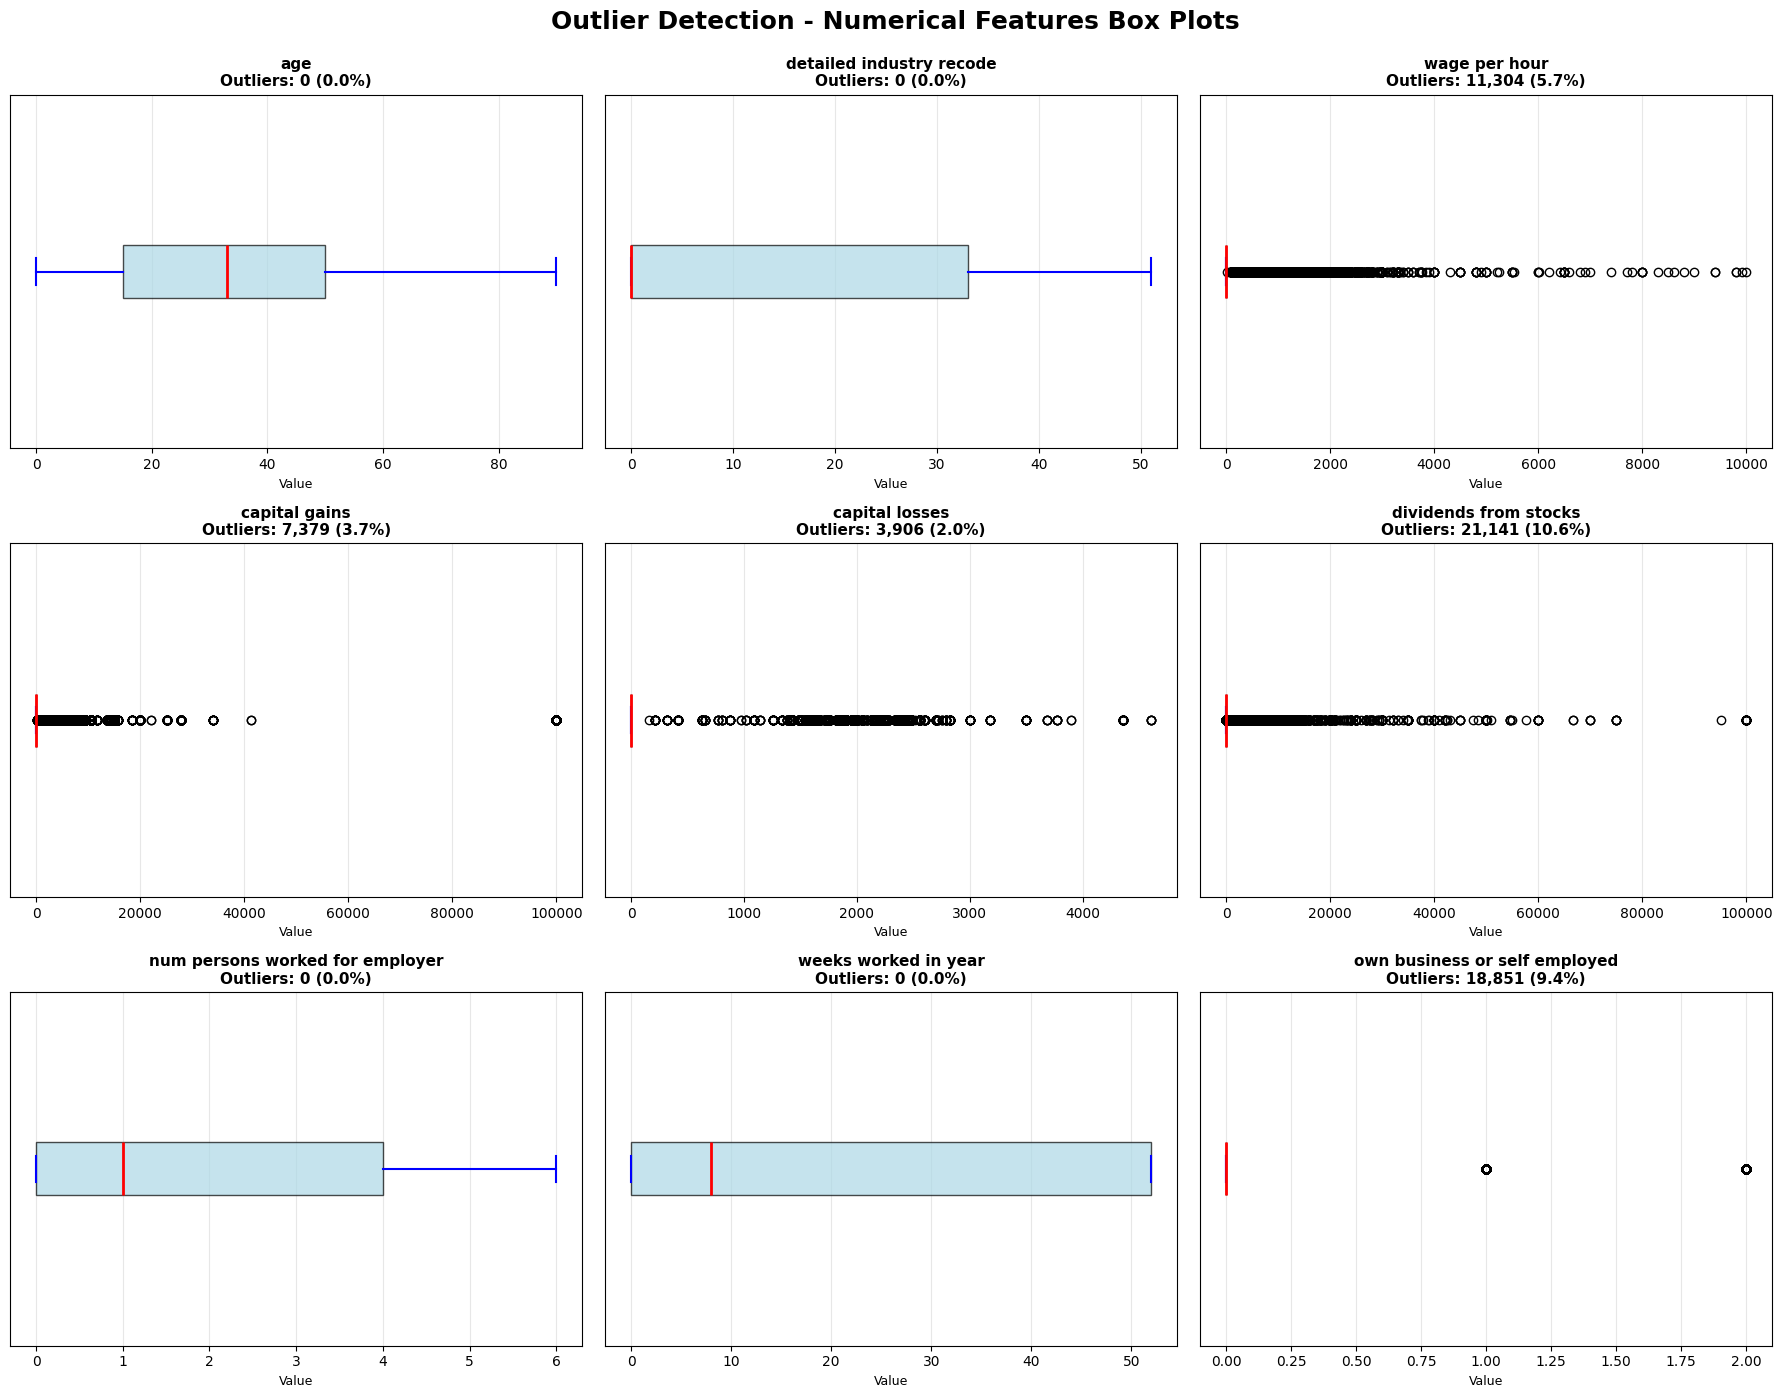

In [25]:
boxplot_cols = [
    'age',
    'detailed industry recode',
    'wage per hour',
    'capital gains',
    'capital losses',
    'dividends from stocks',
    'num persons worked for employer',
    'weeks worked in year',
    'own business or self employed'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for idx, col in enumerate(boxplot_cols):
    ax = axes[idx]
    
    data = df_clean[col].dropna()
    
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    outlier_pct = (len(outliers) / len(data)) * 100
    
    bp = ax.boxplot([data], vert=False, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    whiskerprops=dict(color='blue', linewidth=1.5),
                    capprops=dict(color='blue', linewidth=1.5))
    
    ax.set_title(f'{col}\nOutliers: {len(outliers):,} ({outlier_pct:.1f}%)', 
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Value', fontsize=9)
    ax.set_yticks([])
    ax.grid(alpha=0.3, axis='x')

fig.suptitle('Outlier Detection - Numerical Features Box Plots', 
             fontsize=18, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

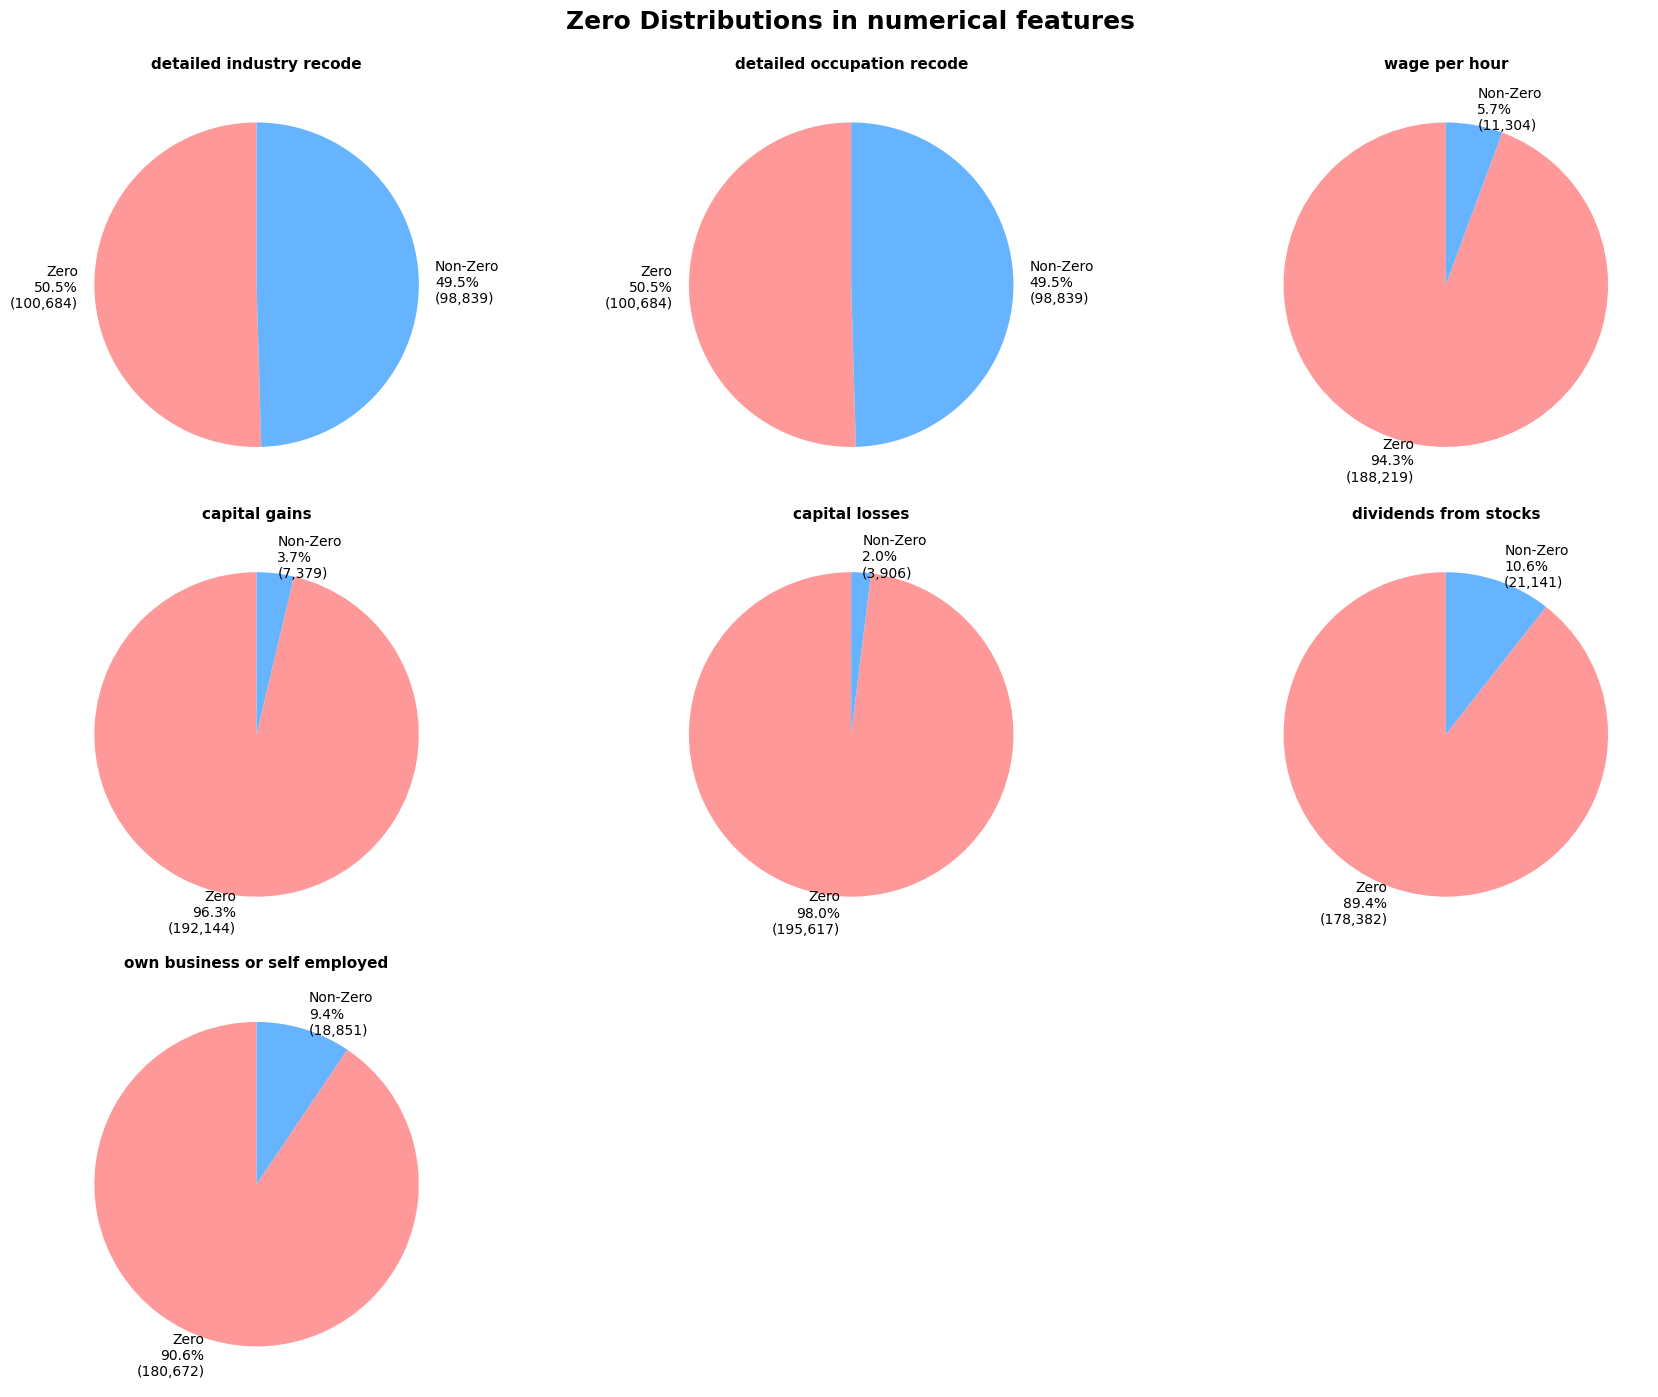

In [26]:
# Columns with high zero percentages
zero_heavy_cols = [
    'detailed industry recode',
    'detailed occupation recode', 
    'wage per hour',
    'capital gains',
    'capital losses',
    'dividends from stocks',
    'own business or self employed'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for idx, col in enumerate(zero_heavy_cols):
    ax = axes[idx]
    

    zero_count = (df_clean[col] == 0).sum()
    nonzero_count = (df_clean[col] != 0).sum()
    zero_pct = (zero_count / len(df_clean)) * 100
    nonzero_pct = (nonzero_count / len(df_clean)) * 100

    colors = ['#ff9999', '#66b3ff']
    sizes = [zero_count, nonzero_count]
    labels = [f'Zero\n{zero_pct:.1f}%\n({zero_count:,})', 
              f'Non-Zero\n{nonzero_pct:.1f}%\n({nonzero_count:,})']
    
    ax.pie(sizes, labels=labels, colors=colors, autopct='', 
           startangle=90, textprops={'fontsize': 10})
    ax.set_title(col, fontsize=11, fontweight='bold', pad=10)

for idx in range(len(zero_heavy_cols), len(axes)):
    fig.delaxes(axes[idx])

fig.suptitle('Zero Distributions in numerical features', 
             fontsize=18, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

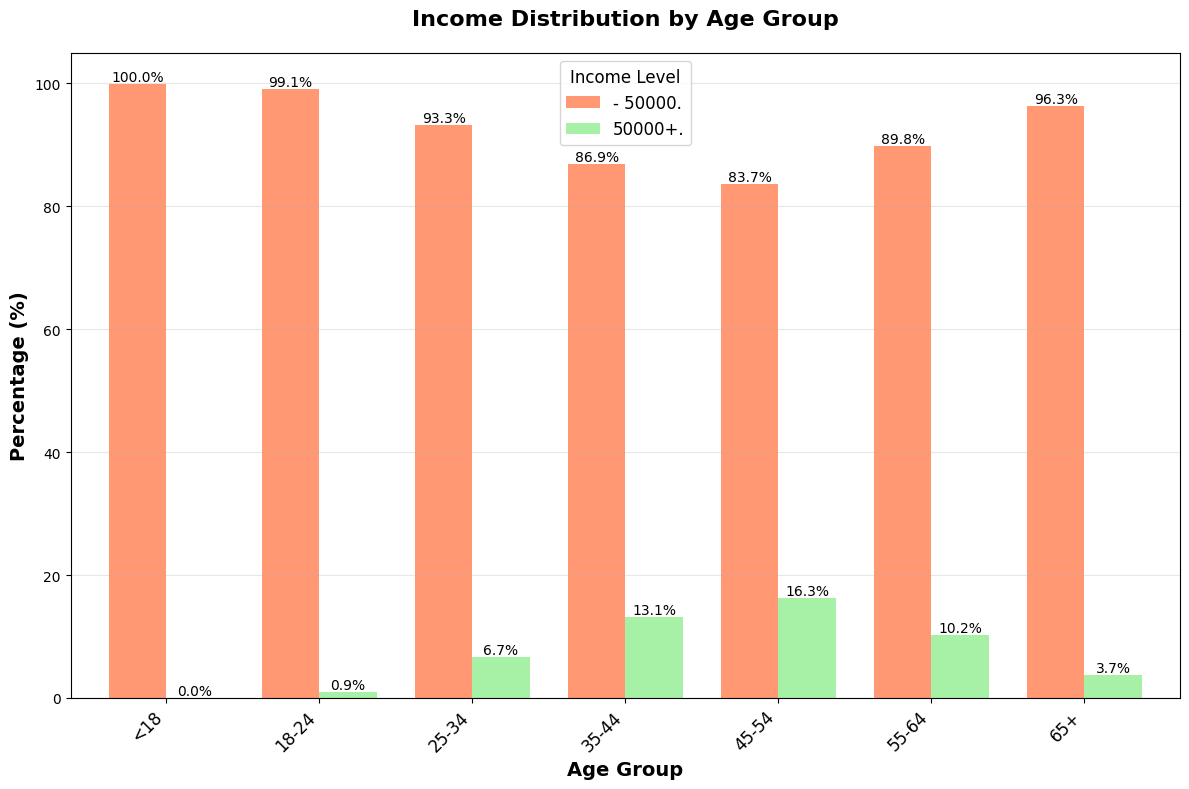

AGE STATISTICS BY INCOME LEVEL

- 50000.:
  Mean age: 33.7
  Median age: 31.0
  Min age: 0
  Max age: 90

50000+.:
  Mean age: 46.3
  Median age: 45.0
  Min age: 16
  Max age: 90


In [27]:
target_col = 'label'

age_bins = [0, 18, 25, 35, 45, 55, 65, 100]
age_labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df_clean['age_group'] = pd.cut(df_clean['age'], bins=age_bins, labels=age_labels)

fig, ax = plt.subplots(figsize=(12, 8))

age_income = pd.crosstab(df_clean['age_group'], df_clean[target_col], normalize='index') * 100

age_income.plot(kind='bar', ax=ax, color=['coral', 'lightgreen'], alpha=0.8, width=0.75)
ax.set_xlabel('Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Income Distribution by Age Group', fontsize=16, fontweight='bold', pad=20)
ax.set_xticklabels(age_labels, rotation=45, ha='right', fontsize=12)
ax.legend(title='Income Level', fontsize=12, title_fontsize=12)
ax.grid(alpha=0.3, axis='y')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10)

plt.tight_layout()
plt.show()

print("AGE STATISTICS BY INCOME LEVEL")

income_categories = df_clean[target_col].unique()
for income_cat in income_categories:
    income_data = df_clean[df_clean[target_col] == income_cat]
    print(f"\n{income_cat}:")
    print(f"  Mean age: {income_data['age'].mean():.1f}")
    print(f"  Median age: {income_data['age'].median():.1f}")
    print(f"  Min age: {income_data['age'].min():.0f}")
    print(f"  Max age: {income_data['age'].max():.0f}")

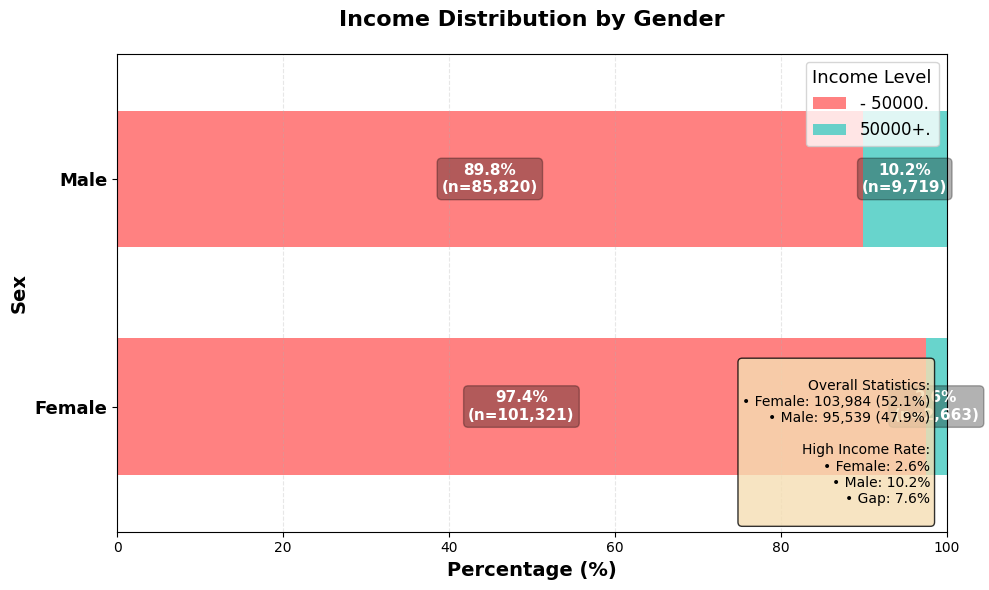

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

crosstab = pd.crosstab(df_clean['sex'], df_clean[target_col])
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100

crosstab_counts = pd.crosstab(df_clean['sex'], df_clean[target_col])

crosstab_pct.plot(kind='barh', ax=ax, stacked=True,
                  color=['#FF6B6B', '#4ECDC4'], alpha=0.85, width=0.6)

ax.set_xlabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Sex', fontsize=14, fontweight='bold')
ax.set_title('Income Distribution by Gender', fontsize=16, fontweight='bold', pad=20)
ax.legend(title='Income Level', fontsize=12, title_fontsize=13, loc='upper right')
ax.set_yticklabels(crosstab_pct.index, fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, axis='x', linestyle='--')
ax.set_xlim(0, 100)

for i, (idx, row) in enumerate(crosstab_pct.iterrows()):
    cumsum = 0
    for j, (col_name, value) in enumerate(row.items()):
        label_x = cumsum + (value / 2)
        
        count = crosstab_counts.loc[idx, col_name]

        ax.text(label_x, i, f'{value:.1f}%\n(n={count:,})', 
                ha='center', va='center', fontsize=11, fontweight='bold',
                color='white', bbox=dict(boxstyle='round,pad=0.3', 
                                        facecolor='black', alpha=0.3))
        cumsum += value

summary_text = f"""
Overall Statistics:
• Female: {len(df_clean[df_clean['sex']=='Female']):,} ({len(df_clean[df_clean['sex']=='Female'])/len(df_clean)*100:.1f}%)
• Male: {len(df_clean[df_clean['sex']=='Male']):,} ({len(df_clean[df_clean['sex']=='Male'])/len(df_clean)*100:.1f}%)

High Income Rate:
• Female: {crosstab_pct.loc['Female'].iloc[1]:.1f}%
• Male: {crosstab_pct.loc['Male'].iloc[1]:.1f}%
• Gap: {abs(crosstab_pct.loc['Male'].iloc[1] - crosstab_pct.loc['Female'].iloc[1]):.1f}%
"""
ax.text(0.98, 0.02, summary_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()


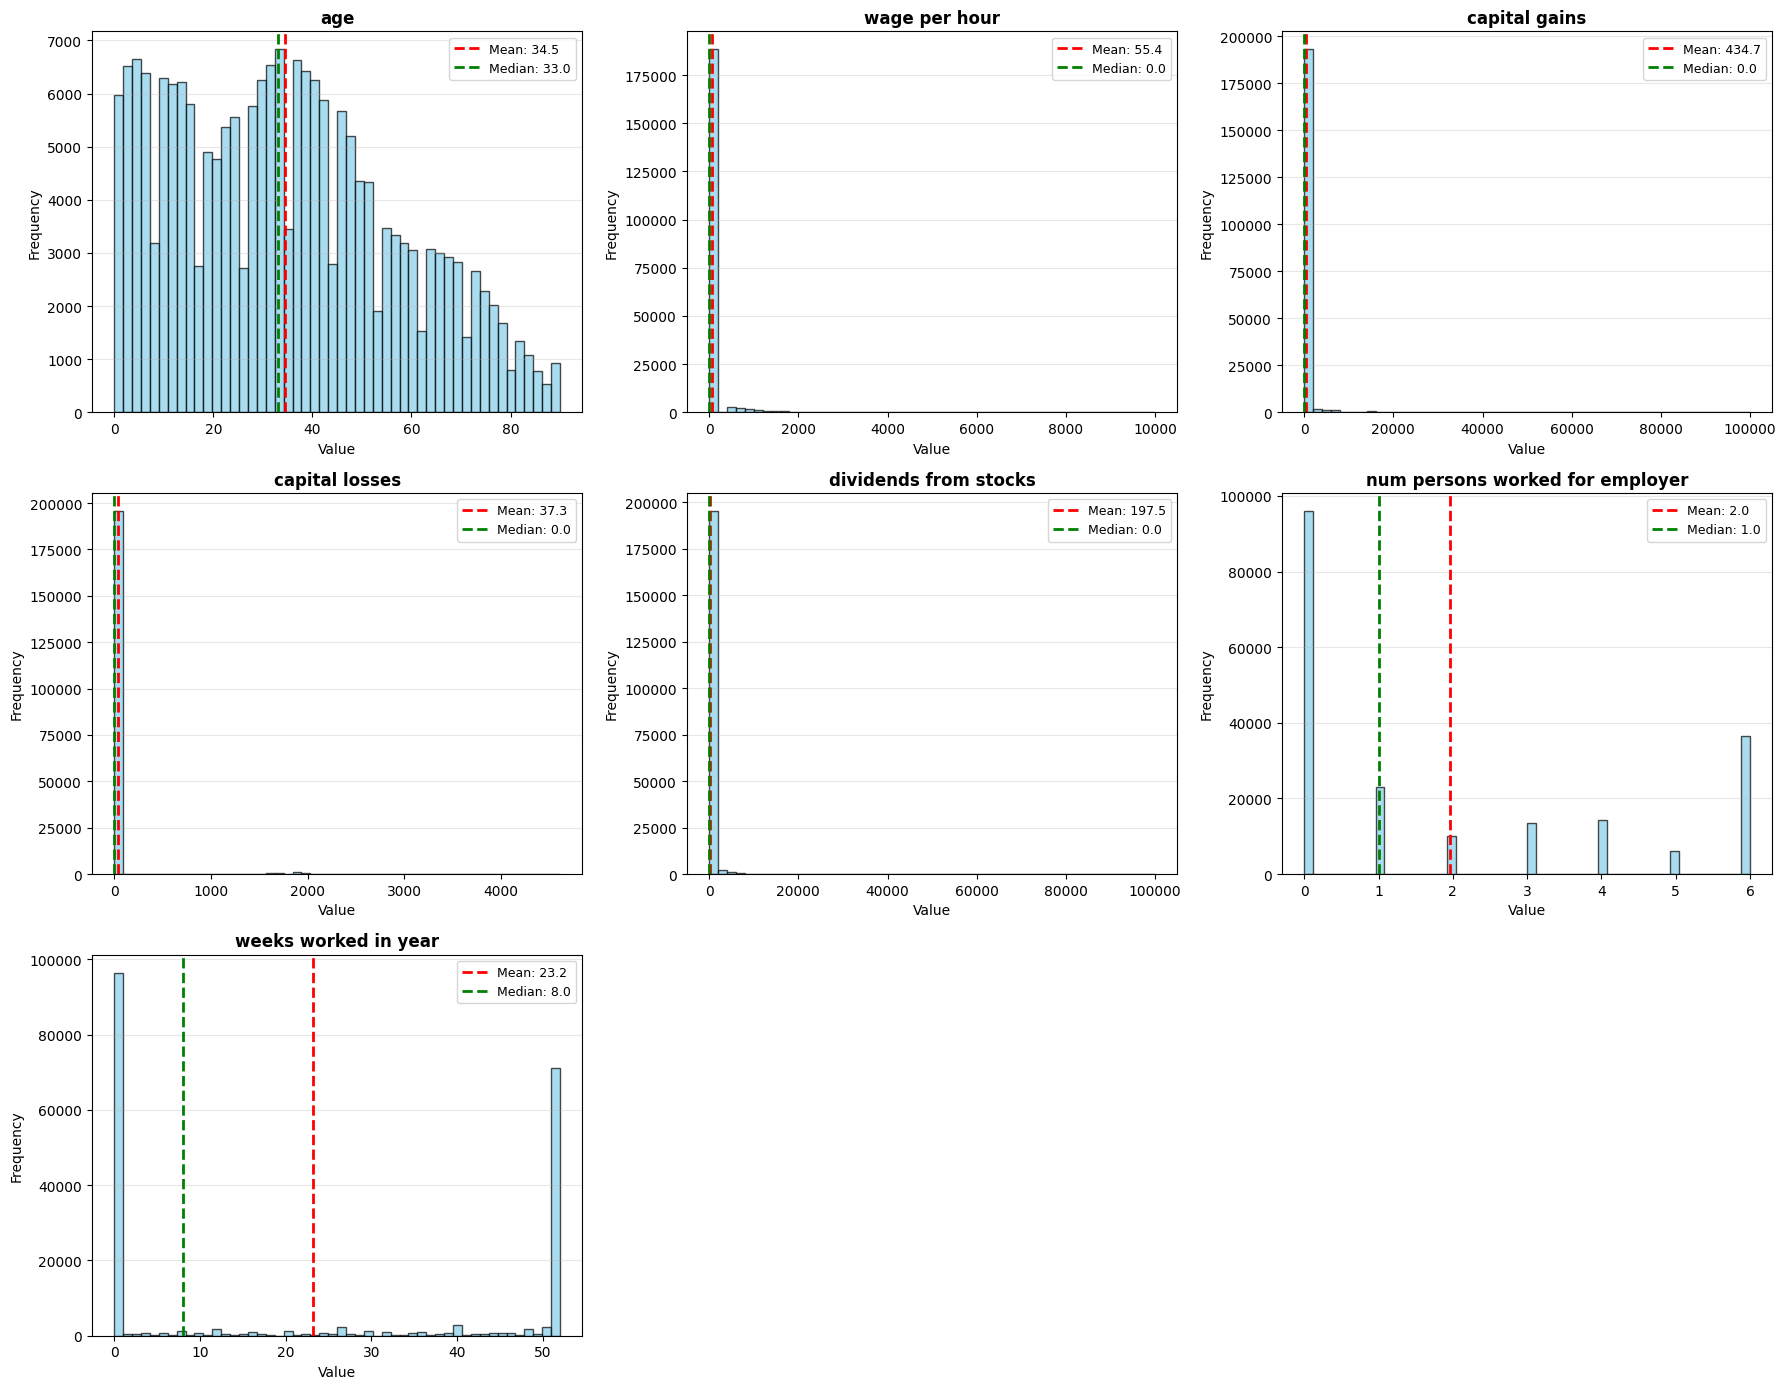

In [29]:
histogram_cols = [
    'age',
    'wage per hour',
    'capital gains',
    'capital losses',
    'dividends from stocks',
    'num persons worked for employer',
    'weeks worked in year'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for idx, col in enumerate(histogram_cols):
    ax = axes[idx]
    

    data = df_clean[col].dropna()
    
    mean_val = data.mean()
    median_val = data.median()
    
    n, bins, patches = ax.hist(data, bins=50, edgecolor='black', 
                                alpha=0.7, color='skyblue')
    
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_val:.1f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2, 
               label=f'Median: {median_val:.1f}')
    

    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Value', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(alpha=0.3, axis='y')

for idx in range(len(histogram_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

In [30]:
duplicates = df_clean.duplicated().sum()
duplicate_pct = (duplicates / len(df_clean)) * 100

print(f"Duplicate rows: {duplicates:,} ({duplicate_pct:.2f}%)")

if duplicates > 0:
    print("\nDuplicates found!")

Duplicate rows: 3,229 (1.62%)

Duplicates found!


<a id='feature-selection'></a>
## 1.4 Feature Selection

Identifying and selecting the most relevant features for modeling while removing redundant or low-information features.

<h4>Feature Selection</h4>

Creating correlation heatmap for 12 numerical columns:
['age', 'detailed industry recode', 'detailed occupation recode', 'wage per hour', 'capital gains', 'capital losses', 'dividends from stocks', 'num persons worked for employer', 'own business or self employed', 'veterans benefits', 'weeks worked in year', 'year']


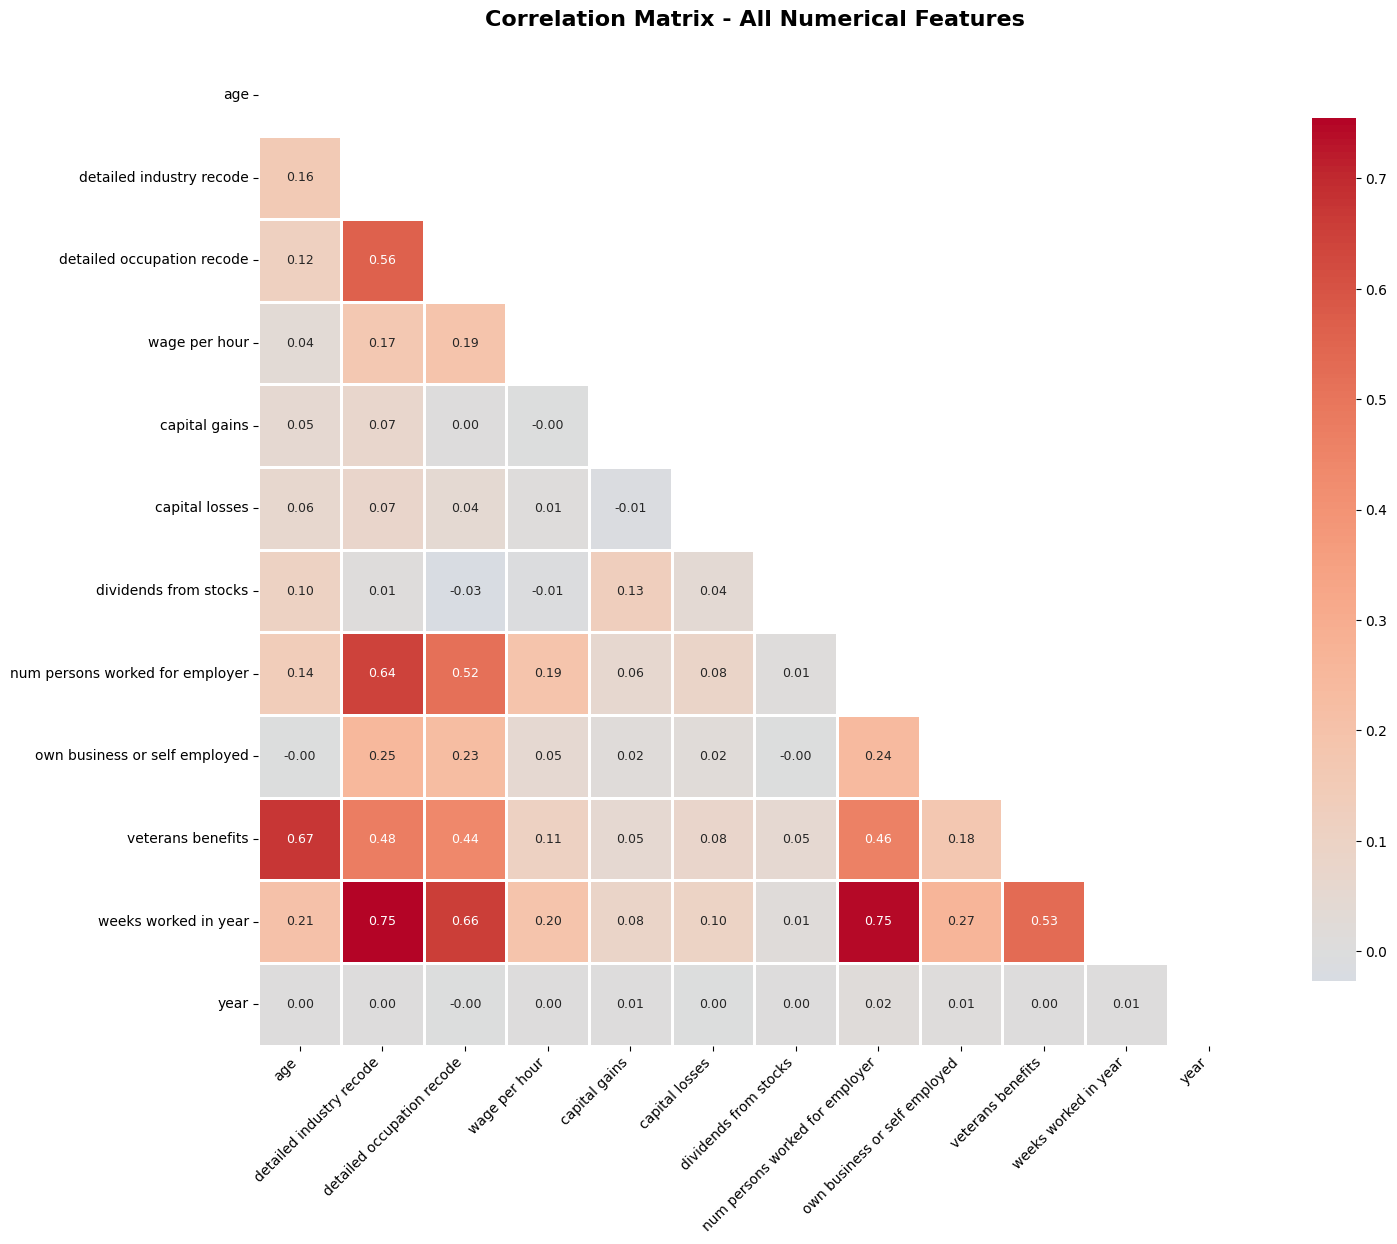

HIGH CORRELATIONS (|r| > 0.5)
                      Feature 1                       Feature 2 Correlation
       detailed industry recode            weeks worked in year       0.754
num persons worked for employer            weeks worked in year       0.747
                            age               veterans benefits       0.675
     detailed occupation recode            weeks worked in year       0.656
       detailed industry recode num persons worked for employer       0.642
       detailed industry recode      detailed occupation recode       0.563
              veterans benefits            weeks worked in year       0.532
     detailed occupation recode num persons worked for employer       0.516


<Figure size 640x480 with 0 Axes>

In [31]:
print(f"Creating correlation heatmap for {len(numerical_cols)} numerical columns:")
print(numerical_cols)

corr_matrix = df_clean[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, 
            linewidths=1, cbar_kws={'shrink': 0.8},
            annot_kws={'fontsize': 9}, ax=ax)

plt.title('Correlation Matrix - All Numerical Features', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10)
plt.show()
plt.tight_layout()

print("HIGH CORRELATIONS (|r| > 0.5)")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            high_corr.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': f"{corr_matrix.iloc[i, j]:.3f}"
            })

if high_corr:
    high_corr_df = pd.DataFrame(high_corr).sort_values('Correlation', ascending=False, key=lambda x: abs(x.astype(float)))
    print(high_corr_df.to_string(index=False))
else:
    print("No correlations > 0.5 found")

Due to high value of cardinality and low high impact information providing . i plan to drop the below rows:
1. fill inc questionnaire for veteran's admin
2. reason for unemployment
3. enroll in edu inst last wk
4. state of previous residence
5. member of a labor union

Due to High Missing Values, ill be dropping teh below and replacing with a single column called has_migration_data:
1. migration code-change in msa
2. migration code-change in reg
3. migration code-move within reg
4. migration prev res in sunbelt

i will also be dropping below column due to high correlation with other industry related data
1. detailed occupation recode
2. major occupation code 

## 1.4 Feature Selection

Based on my exploratory data analysis, the following features will be removed to improve the models performance and reduce dimensionality.

### Features to Drop

#### High Cardinality with Low Information Value

The following features have high cardinality but provide limited predictive information:

1. **fill inc questionnaire for veteran's admin** - Limited variance and relevance
2. **reason for unemployment** - Sparse information for employed individuals
3. **enroll in edu inst last wk** - Temporal feature with limited impact
4. **state of previous residence** - High cardinality, low signal
5. **member of a labor union** - Low information gain

#### High Missing Values - Migration Features

These migration-related features contain substantial missing values and will be replaced with a single engineered feature `has_migration_data`:

- migration code-change in msa
- migration code-change in reg
- migration code-move within reg
- migration prev res in sunbelt

**Rationale:** Instead of imputing multiple sparse features, I have created binary indicators to capture whether migration data is available.

#### High Correlation with Existing Features

The following features are redundant due to high correlation with other occupation/industry variables:

- **detailed occupation recode** - Correlated with major occupation code
- **major occupation code** - Redundant with industry classifications

In [32]:
print("FEATURE SELECTION: DROPPING LOW-VALUE & REDUNDANT FEATURES")

# Group 1: High cardinality with minimal information
low_impact_cols = [
    'fill inc questionnaire for veteran\'s admin',
    'reason for unemployment',
    'enroll in edu inst last wk',
    'state of previous residence',
    'member of a labor union'
]

# Group 2: High missing values , will replace with single flag
migration_cols = [
    'migration code-change in msa',
    'migration code-change in reg',
    'migration code-move within reg',
    'migration prev res in sunbelt'
]

# Group 3: Highly correlated / redundant features
highly_correlated_cols = [
    'detailed occupation recode',
    'major occupation code'
]

FEATURE SELECTION: DROPPING LOW-VALUE & REDUNDANT FEATURES


In [33]:
print("\nCREATING 'has_migration_data' FLAG before dropping columns")

migration_indicators = []

for col in migration_cols:
    if col in df_clean.columns:
        has_data = (
            df_clean[col].notna() & 
            (df_clean[col] != 'Not in universe') &
            (df_clean[col].astype(str) != 'Not in universe')
        )
        migration_indicators.append(has_data)

if migration_indicators:
    df_clean['has_migration_data'] = np.any(migration_indicators, axis=0).astype(int)

    print(f"\n   Created: has_migration_data")


CREATING 'has_migration_data' FLAG before dropping columns

   Created: has_migration_data


In [34]:
print("\nDROPPING COLUMNS")

all_drop_cols = low_impact_cols + migration_cols + highly_correlated_cols

existing_drop_cols = [col for col in all_drop_cols if col in df_clean.columns]
missing_cols = [col for col in all_drop_cols if col not in df_clean.columns]

print("\n   LOW IMPACT / HIGH CARDINALITY:")
for col in low_impact_cols:
    if col in df_clean.columns:
        unique = df_clean[col].nunique()
        print(f"Dropping: {col} ({unique} unique values)")
    else:
        print(f"Not found: {col}")

print("\n   HIGH MISSING VALUES (Replaced with 'has_migration_data'):")
for col in migration_cols:
    if col in df_clean.columns:
        missing_pct = (df_clean[col].isna().sum() / len(df_clean)) * 100
        print(f"Dropping: {col} ({missing_pct:.1f}% missing)")
    else:
        print(f"Not found: {col}")

print("\nREDUNDANT / HIGHLY CORRELATED:")
for col in highly_correlated_cols:
    if col in df_clean.columns:
        print(f"Dropping: {col}")
    else:
        print(f"Not found: {col}")


DROPPING COLUMNS

   LOW IMPACT / HIGH CARDINALITY:
Dropping: fill inc questionnaire for veteran's admin (3 unique values)
Dropping: reason for unemployment (6 unique values)
Dropping: enroll in edu inst last wk (3 unique values)
Dropping: state of previous residence (50 unique values)
Dropping: member of a labor union (3 unique values)

   HIGH MISSING VALUES (Replaced with 'has_migration_data'):
Dropping: migration code-change in msa (50.0% missing)
Dropping: migration code-change in reg (50.0% missing)
Dropping: migration code-move within reg (50.0% missing)
Dropping: migration prev res in sunbelt (50.0% missing)

REDUNDANT / HIGHLY CORRELATED:
Dropping: detailed occupation recode
Dropping: major occupation code


In [35]:
print("\nCREATING df_selected")

df_selected = df_clean.drop(columns=existing_drop_cols, errors='ignore')

print(f"\nOriginal shape: {df_clean.shape}")
print(f"New shape: {df_selected.shape}")
print(f"Columns dropped: {df_clean.shape[1] - df_selected.shape[1]}")
print(f"Remaining columns: {df_selected.shape[1]}")


CREATING df_selected

Original shape: (199523, 44)
New shape: (199523, 33)
Columns dropped: 11
Remaining columns: 33


In [36]:
print("SAVING FILTERED DATASET")
df_selected.to_csv('df_selected.csv', index=False)
print("Saved: df_selected.csv")

SAVING FILTERED DATASET
Saved: df_selected.csv


<a id='feature-engineering'></a>
## 1.5 Feature Engineering

Creating new features and transforming existing ones to improve the model performance.

### 1.5.1 Engineered Features

The following features were engineered:
1. `has_migration` - Migration status indicator
2. Country grouping - Grouping countries of birth into regions
3. Age binning - Creating age groups
4. Net capital - capital gains - capital losses
5. Business ownership - Binary flag for self-employment
6. Veteran benefits - Binary flag for veteran benefits

In [37]:
fe_df = df_selected.copy()

In [38]:
print("\nGROUPING COUNTRY OF BIRTH INTO REGIONS")

if 'country of birth father' in fe_df.columns or 'country of birth mother' in fe_df.columns or 'country of birth self' in fe_df.columns :
    
    # Define regional groupings
    def map_country_to_region(country):
        country = str(country).strip()
        
        # North America
        if country in ['United-States', 'Canada', 'Mexico']:
            return 'North_America'
        
        # Central/South America & Caribbean
        elif any(x in country for x in ['Cuba', 'Jamaica', 'Haiti', 'Dominican', 
                                         'Puerto-Rico', 'El-Salvador', 'Guatemala',
                                         'Nicaragua', 'Honduras', 'Columbia', 'Ecuador',
                                         'Peru', 'Trinadad&Tobago']):
            return 'Latin_America_Caribbean'
        
        # Europe
        elif any(x in country for x in ['England', 'Germany', 'Italy', 'Poland', 
                                         'Portugal', 'France', 'Greece', 'Ireland',
                                         'Scotland', 'Yugoslavia', 'Hungary', 'Holand']):
            return 'Europe'
        
        # Asia
        elif any(x in country for x in ['China', 'India', 'Philippines', 'Vietnam',
                                         'Japan', 'Taiwan', 'Korea', 'Iran', 'Cambodia',
                                         'Laos', 'Thailand', 'Hong', 'Pakistan']):
            return 'Asia'
        
        # Other/Unknown
        elif country in ['Not in universe', 'nan', '']:
            return 'Unknown'
        
        else:
            return 'Other'
    
    # Apply mapping
    fe_df['country_of_birth_father_region'] = fe_df['country of birth father'].apply(map_country_to_region)
    fe_df['country_of_birth_mother_region'] = fe_df['country of birth mother'].apply(map_country_to_region)
    fe_df['country_of_birth_self_region'] = fe_df['country of birth self'].apply(map_country_to_region)
    
    print("Created: country_of_birth_father_region")
    print("Created: country_of_birth_mother_region")
    print("Created: country_of_birth_self_region")
    
    print("\n   Regional distribution (self):")
    print(fe_df['country_of_birth_self_region'].value_counts())
    
else:
    print("Country of birth columns not found")


GROUPING COUNTRY OF BIRTH INTO REGIONS
Created: country_of_birth_father_region
Created: country_of_birth_mother_region
Created: country_of_birth_self_region

   Regional distribution (self):
country_of_birth_self_region
North_America              183456
Latin_America_Caribbean      5896
Asia                         3703
Unknown                      3393
Europe                       2928
Other                         147
Name: count, dtype: int64


In [39]:
print("\nCREATING AGE GROUPS")

if 'age' in fe_df.columns:
    
    age_bins = [0, 18, 25, 35, 45, 55, 65, 100]
    age_labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
    
    fe_df['age_group'] = pd.cut(fe_df['age'], bins=age_bins, labels=age_labels, right=False)
    
    print("Created: age_group")
    
    # Also create broader categories
    fe_df['age_category'] = pd.cut(
        fe_df['age'],
        bins=[0, 18, 65, 100],
        labels=['Minor', 'Working_Age', 'Senior'],
        right=False
    )
    print("\nCreated: age_category (broad)")
    print(f"\nAge category distribution:")
    print(fe_df['age_category'].value_counts())
    
else:
    print("Age column not found")


CREATING AGE GROUPS
Created: age_group

Created: age_category (broad)

Age category distribution:
age_category
Working_Age    119242
Minor           55992
Senior          24289
Name: count, dtype: int64


In [40]:
print("\nCREATING NET CAPITAL INCOME")

if all(col in fe_df.columns for col in ['capital gains', 'capital losses']):
    
    fe_df['net_capital'] = fe_df['capital gains'] - fe_df['capital losses']
    
    print("Created: net_capital (capital_gains - capital_losses)")


CREATING NET CAPITAL INCOME
Created: net_capital (capital_gains - capital_losses)


In [41]:
print("\nCONVERTING SELF-EMPLOYMENT TO BINARY FLAG")

if 'own business or self employed' in fe_df.columns:
    
    fe_df['is_self_employed'] = (fe_df['own business or self employed'] > 0).astype(int)
    
    print("Created: is_self_employed")


CONVERTING SELF-EMPLOYMENT TO BINARY FLAG
Created: is_self_employed


In [42]:
print("\nCONVERTING VETERANS BENEFITS TO BINARY FLAG")
if 'veterans benefits' in fe_df.columns:
    
    # Create binary flag
    fe_df['has_veteran_benefits'] = (fe_df['veterans benefits'] > 0).astype(int)
    
    print("Created: has_veteran_benefits")


CONVERTING VETERANS BENEFITS TO BINARY FLAG
Created: has_veteran_benefits


In [43]:
if 'education' in fe_df.columns:
    education_order = {
        'Children': 0,
        'Less than 1st grade': 1,
        '1st 2nd 3rd or 4th grade': 2,
        '5th or 6th grade': 3,
        '7th and 8th grade': 4,
        '9th grade': 5,
        '10th grade': 6,
        '11th grade': 7,
        '12th grade no diploma': 8,
        'High school graduate': 9,
        'Some college but no degree': 10,
        'Associates degree-occup /vocational': 11,
        'Associates degree-academic program': 12,
        'Bachelors degree(BA AB BS)': 13,
        'Masters degree(MA MS MEng MEd MSW MBA)': 14,
        'Prof school degree (MD DDS DVM LLB JD)': 15,
        'Doctorate degree(PhD EdD)': 16
    }
    fe_df['education_level'] = fe_df['education'].map(education_order)
    print("Created: education_level (ordinal)")

Created: education_level (ordinal)


<a id='preprocessing'></a>
## 1.6 Data Preprocessing

Handling missing values, encoding categorical variables, and preparing data for modelling.

### 1.6.1 Missing Value Imputation

<h4>Null Handling</h4>

In [44]:
fe_df['hispanic origin'] = fe_df['hispanic origin'].fillna('Unknown')

In [45]:
print("PERCENTILE CAPPING TO HANDLE OUTLIER")

fe_df_capped = fe_df.copy()

# Wage per hour is capped at 99th percentile
if 'wage per hour' in fe_df_capped.columns:
    non_zero_wage = fe_df_capped[fe_df_capped['wage per hour'] > 0]['wage per hour']
    
    if len(non_zero_wage) > 0:
        cap_99 = non_zero_wage.quantile(0.99)
        
        fe_df_capped['wage_per_hour_capped'] = fe_df_capped['wage per hour'].copy()
        fe_df_capped.loc[fe_df_capped['wage_per_hour_capped'] > cap_99, 'wage_per_hour_capped'] = cap_99
        
        
        print(f"\nWAGE PER HOUR:")
        print(f"99th percentile: ${cap_99:.2f}")
        print(f"Original max: ${fe_df['wage per hour'].max():.2f}")
        print(f"New max: ${fe_df_capped['wage_per_hour_capped'].max():.2f}")
        print("Created: wage_per_hour_capped")

# Dividends are capped at 99th percentile
if 'dividends from stocks' in fe_df_capped.columns:
    non_zero_div = fe_df_capped[fe_df_capped['dividends from stocks'] > 0]['dividends from stocks']
    
    if len(non_zero_div) > 0:
        cap_99 = non_zero_div.quantile(0.99)
        
        fe_df_capped['dividends_capped'] = fe_df_capped['dividends from stocks'].copy()
        fe_df_capped.loc[fe_df_capped['dividends_capped'] > cap_99, 'dividends_capped'] = cap_99
        
        capped_count = (fe_df_capped['dividends from stocks'] > cap_99).sum()
        
        print(f"\nDIVIDENDS FROM STOCKS:")
        print(f"99th percentile: ${cap_99:.2f}")
        print(f"Original max: ${fe_df['dividends from stocks'].max():.2f}")
        print(f"New max: ${fe_df_capped['dividends_capped'].max():.2f}")
        print("Created: dividends_capped")


PERCENTILE CAPPING TO HANDLE OUTLIER

WAGE PER HOUR:
99th percentile: $3000.00
Original max: $9999.00
New max: $3000.00
Created: wage_per_hour_capped

DIVIDENDS FROM STOCKS:
99th percentile: $25000.00
Original max: $99999.00
New max: $25000.00
Created: dividends_capped


In [46]:
fe_df_capped.to_csv("after_feature_engineering.csv")

<a id='training'></a>
## 1.7 Model Training

In [47]:
df_training = pd.read_csv("after_feature_engineering.csv",index_col=0)

In [48]:
df_training.columns

Index(['age', 'class of worker', 'detailed industry recode', 'education',
       'wage per hour', 'marital stat', 'major industry code', 'race',
       'hispanic origin', 'sex', 'full or part time employment stat',
       'capital gains', 'capital losses', 'dividends from stocks',
       'tax filer stat', 'region of previous residence',
       'detailed household and family stat',
       'detailed household summary in household', 'weight',
       'live in this house 1 year ago', 'num persons worked for employer',
       'family members under 18', 'country of birth father',
       'country of birth mother', 'country of birth self', 'citizenship',
       'own business or self employed', 'veterans benefits',
       'weeks worked in year', 'year', 'label', 'age_group',
       'has_migration_data', 'country_of_birth_father_region',
       'country_of_birth_mother_region', 'country_of_birth_self_region',
       'age_category', 'net_capital', 'is_self_employed',
       'has_veteran_benefits',

In [49]:
df_training['label'].value_counts()

label
- 50000.    187141
50000+.      12382
Name: count, dtype: int64

In [50]:
exclude_cols = [
    'label',  
    'weight',  
    'year',   
    
    # Original versions replaced by engineered versions
    'wage per hour',  
    'dividends from stocks',  
    'capital gains',  
    'capital losses',  
    'own business or self employed',  
    'veterans benefits',  
    'age', 
    
    # Original country columns 
    'country of birth father',
    'country of birth mother', 
    'country of birth self',
]

In [51]:
modeling_features = [col for col in df_training.columns if col not in exclude_cols]
print(modeling_features)

['class of worker', 'detailed industry recode', 'education', 'marital stat', 'major industry code', 'race', 'hispanic origin', 'sex', 'full or part time employment stat', 'tax filer stat', 'region of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'live in this house 1 year ago', 'num persons worked for employer', 'family members under 18', 'citizenship', 'weeks worked in year', 'age_group', 'has_migration_data', 'country_of_birth_father_region', 'country_of_birth_mother_region', 'country_of_birth_self_region', 'age_category', 'net_capital', 'is_self_employed', 'has_veteran_benefits', 'education_level', 'wage_per_hour_capped', 'dividends_capped']


In [52]:
numerical_features = [
    'num persons worked for employer',
    'weeks worked in year',
    'net_capital',
    'wage_per_hour_capped',
    'dividends_capped',
    'has_migration_data',
    'is_self_employed',
    'has_veteran_benefits',
    'has_dividends',
    'has_migration_data'
]

categorical_features = [
    'sex',
    'race',
    'hispanic origin',
    'citizenship',
    'marital stat',
    'class of worker',
    'education',
    'major industry code',
    'detailed industry recode',
    'full or part time employment stat',
    'detailed household and family stat',
    'detailed household summary in household',
    'family members under 18',
    'live in this house 1 year ago',
    'region of previous residence',
    'tax filer stat',
    'age_group',
    'country_of_birth_father_region',
    'country_of_birth_mother_region',
    'country_of_birth_self_region',
    'age_category'
]

In [53]:
X = df_training[modeling_features].copy()
y = (df_training['label'] == '50000+.').astype(int)  
weights = df_training['weight'] if 'weight' in df_training.columns else None

le_dict = {}
for col in categorical_features:
    if col in X.columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        le_dict[col] = le

In [54]:
# separating test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Seperating train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

if weights is not None:
    weights_temp, w_test, _, _ = train_test_split(
        weights, y, test_size=0.2, random_state=42, stratify=y
    )
    
    w_train, w_val, _, _ = train_test_split(
        weights_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
    )
else:
    w_train, w_val, w_test = None, None, None

In [55]:
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")
print(f"Class distribution - Train: {np.bincount(y_train)}")
print(f"Class distribution - Val: {np.bincount(y_val)}")
print(f"Class distribution - Test: {np.bincount(y_test)}\n")

Training samples: 127694
Validation samples: 31924
Test samples: 39905
Class distribution - Train: [119769   7925]
Class distribution - Val: [29943  1981]
Class distribution - Test: [37429  2476]



<a id='weights'></a>
### 1.7.1 Training with Sample Weights

<h4> Training with weights - Using sample weights to address class imbalance during model training. </h4>

In [56]:
model_both = XGBClassifier(
n_estimators=100,
max_depth=6,
learning_rate=0.1,
random_state=42,
eval_metric='logloss',
scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]) # Handle imbalance
)

model_both.fit(X_train, y_train, sample_weight=w_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [57]:
# Predictions
y_pred = model_both.predict(X_test)
y_pred_proba = model_both.predict_proba(X_test)[:, 1]

In [58]:
# Evaluation
print("\nXGBoost Performance:")
print(classification_report(y_test, y_pred, target_names=['<50K', '>=50K']))
print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")


XGBoost Performance:
              precision    recall  f1-score   support

        <50K       0.99      0.86      0.92     37429
       >=50K       0.30      0.88      0.44      2476

    accuracy                           0.86     39905
   macro avg       0.64      0.87      0.68     39905
weighted avg       0.95      0.86      0.89     39905


ROC-AUC Score: 0.9479


<a id='imbalance'></a>
### 1.7.2 Training with Class Imbalance Handling

<h4>Training without weights, just handling class imbalance - Alternative approach using class weight balancing instead of sample weights.</h4>

In [59]:
# Train XGBoost
model_scale = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1])  # To Handle class imbalance
)

model_scale.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

<a id='testing'></a>
## 1.8 Model Testing and Evaluation

<h4>Testing </h4>

In [60]:
# Predictions
y_pred = model_scale.predict(X_test)
y_pred_proba = model_scale.predict_proba(X_test)[:, 1]

In [61]:
# Evaluation
print("\nXGBoost Performance:")
print(classification_report(y_test, y_pred, target_names=['<50K', '>=50K']))
print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")


XGBoost Performance:
              precision    recall  f1-score   support

        <50K       0.99      0.86      0.92     37429
       >=50K       0.30      0.89      0.45      2476

    accuracy                           0.87     39905
   macro avg       0.65      0.88      0.69     39905
weighted avg       0.95      0.87      0.89     39905


ROC-AUC Score: 0.9490


<a id='tuning'></a>
## 1.9 Hyperparameter Tuning

Optimizing model performance through systematic hyperparameter search.

In [62]:
print("THRESHOLD OPTIMIZATION using Validation Set")

y_val_proba = model_scale.predict_proba(X_val)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"\nOptimal Threshold: {optimal_threshold:.4f}")
print(f"Best F1-Score (validation): {f1_scores[optimal_idx]:.4f}")

THRESHOLD OPTIMIZATION using Validation Set

Optimal Threshold: 0.8528
Best F1-Score (validation): 0.6110


In [63]:
y_val_pred_optimal = (y_val_proba >= optimal_threshold).astype(int)

print("\nValidation Set Performance (with optimal threshold):")
print(classification_report(y_val, y_val_pred_optimal, target_names=['<50K', '>=50K']))
print(f"ROC-AUC Score (validation): {roc_auc_score(y_val, y_val_proba):.4f}")


Validation Set Performance (with optimal threshold):
              precision    recall  f1-score   support

        <50K       0.97      0.98      0.97     29943
       >=50K       0.62      0.60      0.61      1981

    accuracy                           0.95     31924
   macro avg       0.80      0.79      0.79     31924
weighted avg       0.95      0.95      0.95     31924

ROC-AUC Score (validation): 0.9501


In [64]:
print("FINAL TEST SET EVALUATION")

y_test_proba = model_scale.predict_proba(X_test)[:, 1]

# Applying optimal threshold found on validation set
y_test_pred_optimal = (y_test_proba >= optimal_threshold).astype(int)

# Also getting default 0.5 threshold predictions for comparison
y_test_pred_default = model_scale.predict(X_test)

print("\n--- Performance with Default Threshold (0.5) ---")
print(classification_report(y_test, y_test_pred_default, target_names=['<50K', '>=50K']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_test_proba):.4f}")

print(f"\n--- Performance with Optimal Threshold ({optimal_threshold:.2f}) ---")
print(classification_report(y_test, y_test_pred_optimal, target_names=['<50K', '>=50K']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_test_proba):.4f}")

FINAL TEST SET EVALUATION

--- Performance with Default Threshold (0.5) ---
              precision    recall  f1-score   support

        <50K       0.99      0.86      0.92     37429
       >=50K       0.30      0.89      0.45      2476

    accuracy                           0.87     39905
   macro avg       0.65      0.88      0.69     39905
weighted avg       0.95      0.87      0.89     39905

ROC-AUC Score: 0.9490

--- Performance with Optimal Threshold (0.85) ---
              precision    recall  f1-score   support

        <50K       0.97      0.97      0.97     37429
       >=50K       0.60      0.60      0.60      2476

    accuracy                           0.95     39905
   macro avg       0.79      0.79      0.79     39905
weighted avg       0.95      0.95      0.95     39905

ROC-AUC Score: 0.9490


In [65]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_scale.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))


Top 15 Most Important Features:
                                Feature  Importance
                   weeks worked in year    0.316954
                        education_level    0.175169
                                    sex    0.103912
     detailed household and family stat    0.057353
                       dividends_capped    0.046972
                              age_group    0.042734
                            net_capital    0.031144
detailed household summary in household    0.024331
                           marital stat    0.018450
        num persons worked for employer    0.017488
                   wage_per_hour_capped    0.016916
                         tax filer stat    0.015863
                        class of worker    0.013977
                     has_migration_data    0.013889
               detailed industry recode    0.011913


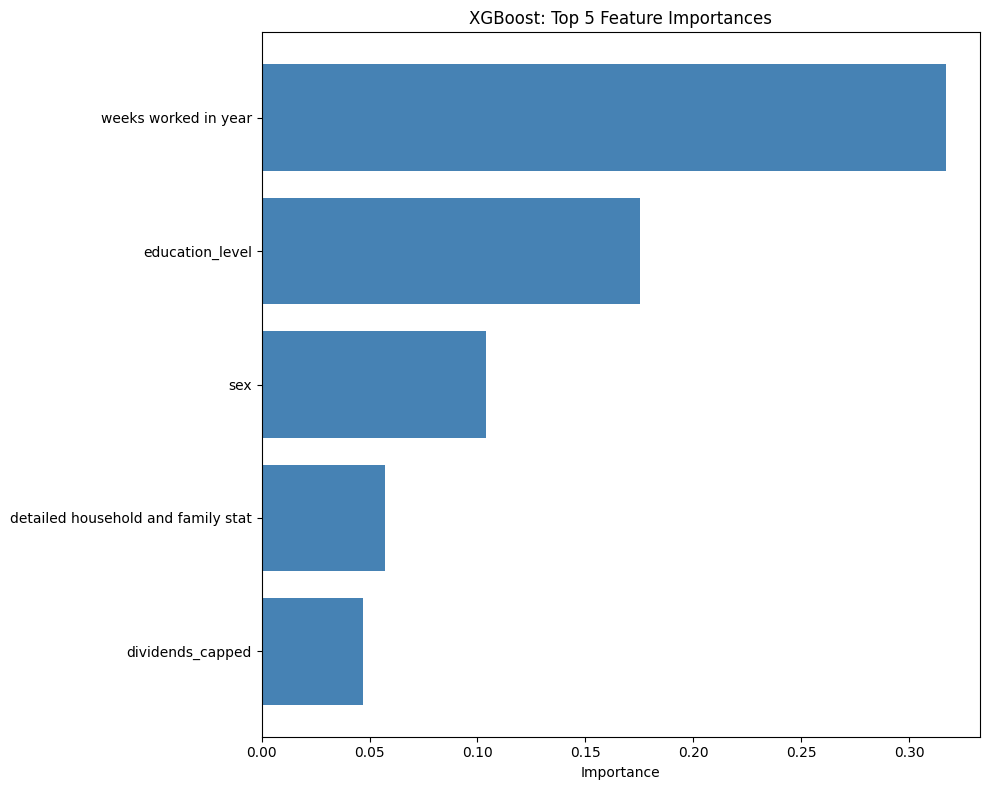

In [66]:
# Plot feature importance
plt.figure(figsize=(10, 8))
plt.barh(range(5), feature_importance['Importance'].head(5), color='steelblue')
plt.yticks(range(5), feature_importance['Feature'].head(5))
plt.xlabel('Importance')
plt.title('XGBoost: Top 5 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('xgboost_feature_importance.png', dpi=300)
plt.show()

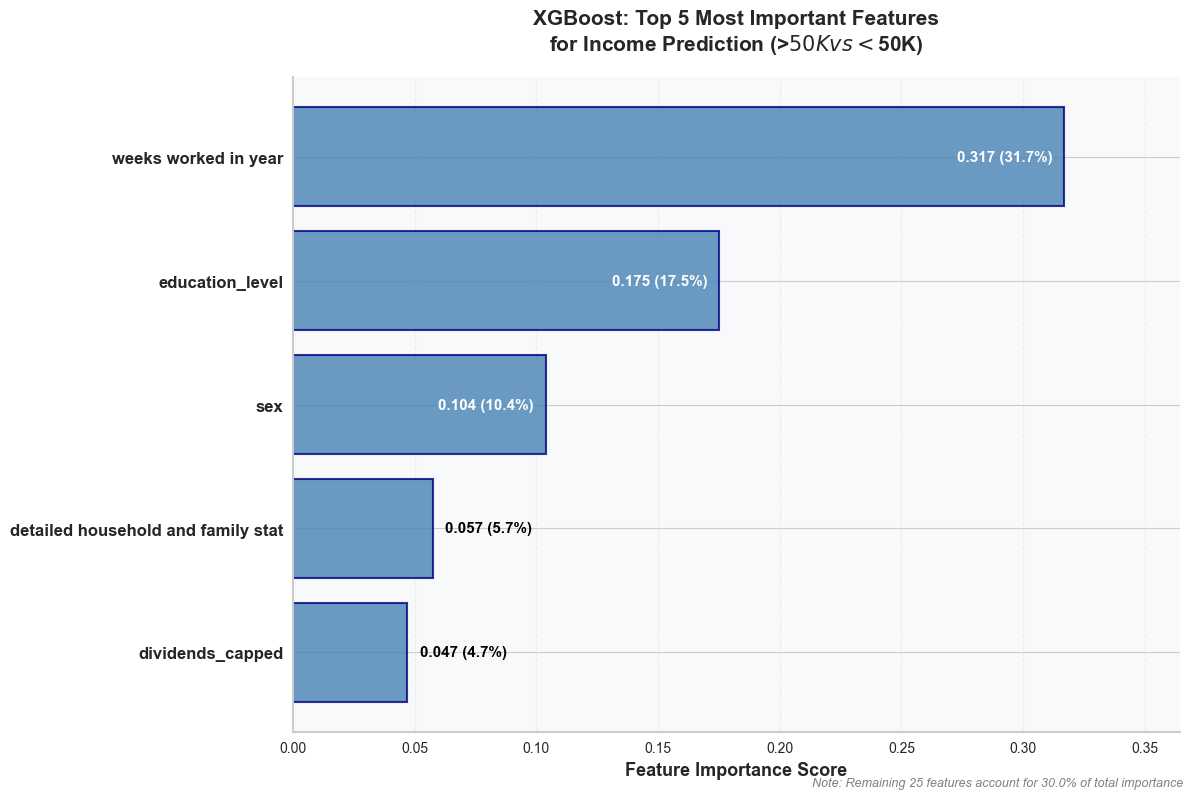

In [70]:
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

fig, ax = plt.subplots(figsize=(12, 8))

# Get top 5 features
top_features = feature_importance.head(5)

bars = ax.barh(
    range(len(top_features)), 
    top_features['Importance'],
    color='steelblue',
    edgecolor='navy',
    linewidth=1.5,
    alpha=0.8
)

total_importance = feature_importance['Importance'].sum()
for i, (idx, row) in enumerate(top_features.iterrows()):
    importance = row['Importance']
    percentage = (importance / total_importance) * 100
    
    if importance > top_features['Importance'].max() * 0.3:
        ax.text(importance - 0.005, i, f'{importance:.3f} ({percentage:.1f}%)', 
                va='center', ha='right', fontsize=11, fontweight='bold', color='white')
    else:
        ax.text(importance + 0.005, i, f'{importance:.3f} ({percentage:.1f}%)', 
                va='center', ha='left', fontsize=11, fontweight='bold', color='black')

ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'], fontsize=12, fontweight='bold')
ax.set_xlabel('Feature Importance Score', fontsize=13, fontweight='bold')
ax.set_title('XGBoost: Top 5 Most Important Features\nfor Income Prediction (>$50K vs <$50K)', 
             fontsize=15, fontweight='bold', pad=20)

ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)

ax.invert_yaxis()

ax.set_facecolor('#f8f9fa')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.set_xlim(0, top_features['Importance'].max() * 1.15)

remaining_pct = ((total_importance - top_features['Importance'].sum()) / total_importance) * 100
plt.figtext(0.99, 0.01, f'Note: Remaining {len(feature_importance) - 5} features account for {remaining_pct:.1f}% of total importance', 
            ha='right', fontsize=9, style='italic', color='gray')

# Tight layout and save
plt.tight_layout()
plt.savefig('xgboost_feature_importance_enhanced.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

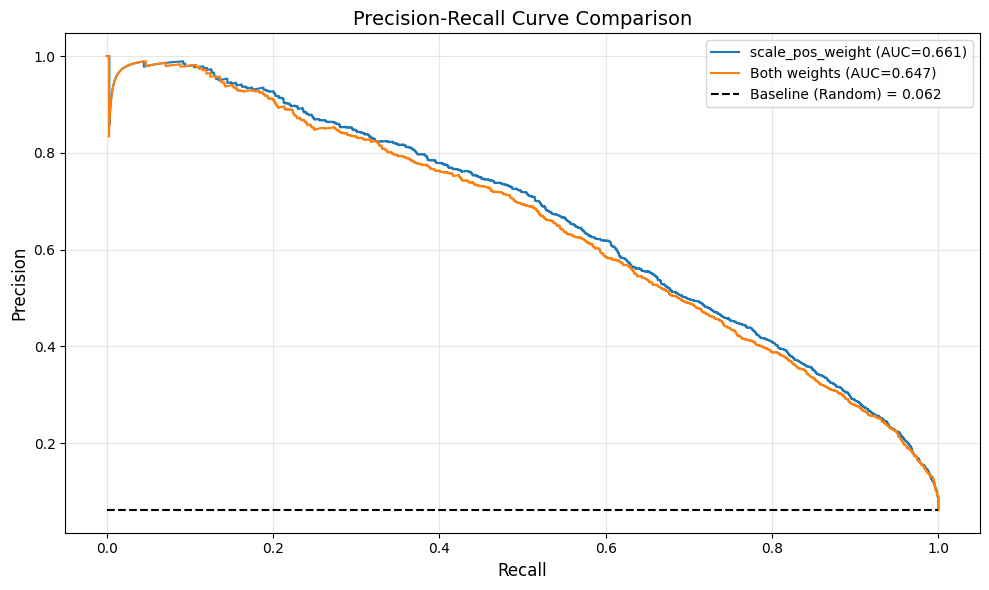

In [67]:
# For each model
models = {'scale_pos_weight': model_scale, 'Both weights': model_both}

plt.figure(figsize=(10, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_val)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_val, y_proba)
    pr_auc = auc(recall, precision)
    
    plt.plot(recall, precision, label=f'{name} (AUC={pr_auc:.3f})')

baseline = len(y_val[y_val==1]) / len(y_val)
plt.plot([0, 1], [baseline, baseline], 'k--', label=f'Baseline (Random) = {baseline:.3f}')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve Comparison', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

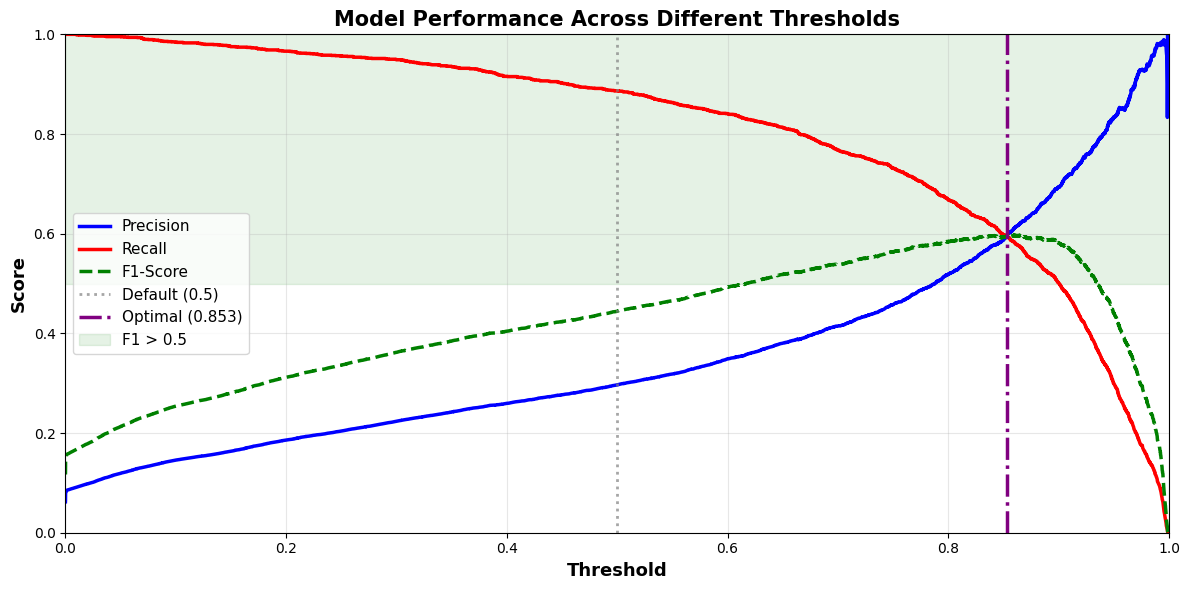

Optimal Threshold: 0.85
At optimal threshold - Precision: 0.584, Recall: 0.601, F1: 0.592


In [68]:
f1_scores = np.where(
    (precision[:-1] + recall[:-1]) == 0,
    0,
    2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])
)
f1_scores = np.nan_to_num(f1_scores, nan=0.0)

plt.figure(figsize=(12, 6))
plt.plot(thresholds, precision[:-1], label='Precision', linewidth=2.5, color='blue')
plt.plot(thresholds, recall[:-1], label='Recall', linewidth=2.5, color='red')
plt.plot(thresholds, f1_scores, label='F1-Score', linewidth=2.5, color='green', linestyle='--')

plt.axvline(0.5, color='gray', linestyle=':', linewidth=2, alpha=0.7, label='Default (0.5)')
plt.axvline(optimal_threshold, color='purple', linestyle='-.', linewidth=2.5, 
            label=f'Optimal ({optimal_threshold:.3f})')

good_f1_indices = f1_scores > 0.5
if any(good_f1_indices):
    plt.axhspan(0.5, 1.0, alpha=0.1, color='green', label='F1 > 0.5')

plt.xlabel('Threshold', fontsize=13, fontweight='bold')
plt.ylabel('Score', fontsize=13, fontweight='bold')
plt.title('Model Performance Across Different Thresholds', fontsize=15, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"At optimal threshold - Precision: {precision[optimal_idx]:.3f}, Recall: {recall[optimal_idx]:.3f}, F1: {f1_scores[optimal_idx]:.3f}")


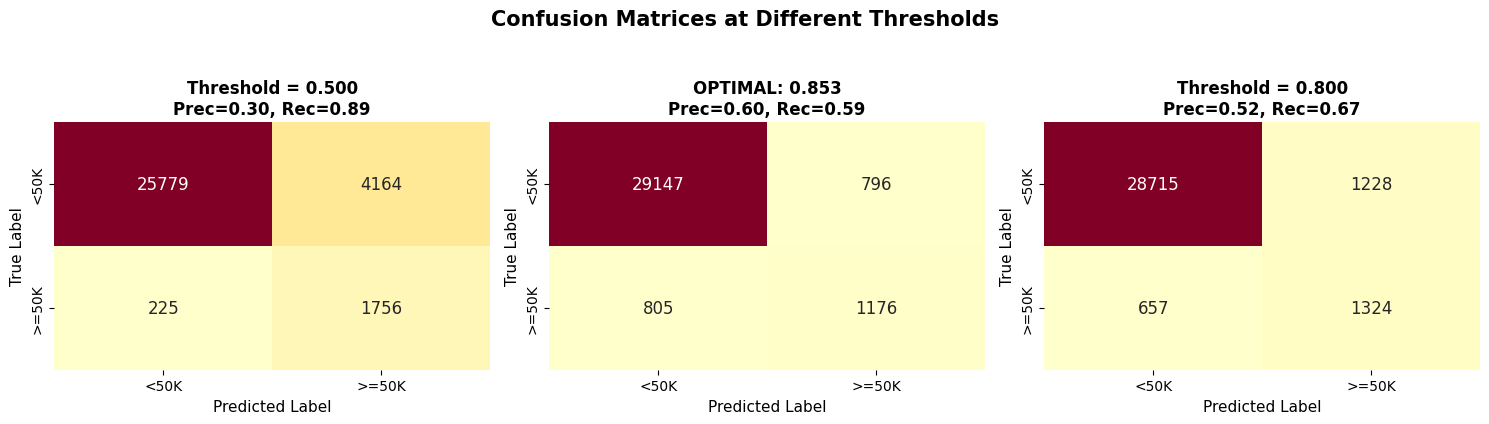

In [69]:
thresholds_to_show = [0.5, optimal_threshold, 0.8]

fig, axes = plt.subplots(1, len(thresholds_to_show), figsize=(15, 4))

for idx, thresh in enumerate(thresholds_to_show):
    y_pred = (y_proba >= thresh).astype(int)
    cm = confusion_matrix(y_val, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[idx],
                xticklabels=['<50K', '>=50K'], yticklabels=['<50K', '>=50K'],
                cbar=False, annot_kws={'fontsize': 12})
    
    tn, fp, fn, tp = cm.ravel()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    title = f'Threshold = {thresh:.3f}\nPrec={prec:.2f}, Rec={rec:.2f}'
    if thresh == optimal_threshold:
        title = f'OPTIMAL: {thresh:.3f}\nPrec={prec:.2f}, Rec={rec:.2f}'
        axes[idx].set_facecolor('#f0f0ff')
    
    axes[idx].set_title(title, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=11)
    axes[idx].set_xlabel('Predicted Label', fontsize=11)

plt.suptitle('Confusion Matrices at Different Thresholds', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


---
## END